In [34]:
from newGeo.dtGeometry import *
from itertools import chain
import logging
# MAPPING DIGIS
def create_wire_position_mapping(df_geometry):
    """
    Creates a mapping from (chamber_rawId, superLayerNumber, layerNumber, wire_number)
    to (x_position, y_position) for all wires in the geometry dataframe.

    Parameters:
        df_geometry (pd.DataFrame): DataFrame with geometry data.

    Returns:
        dict: Mapping from (chamber_rawId, superLayerNumber, layerNumber, wire_number)
              to (x, y) position of each wire.
    """
    mapping = {}

    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_first = int(row['Channels_first'])
        channels_last = int(row['Channels_last'])
        channels_total = channels_last - channels_first + 1
        wireFirst = float(row['WirePositions_FirstWire'])
        wireLast = float(row['WirePositions_LastWire'])
        layer_y = float(row['Layer_Local_z'])

        # Create Wire object
        wire_obj = Wire(wireFirst, wireLast, channels_total, layer_y)

        # Map wire numbers (actual channel IDs) to positions
        for i, x_pos in enumerate(wire_obj.positions):
            wire_number = channels_first + i  # Actual channel ID
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = (x_pos, wire_obj.layer_y)

    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    y_positions = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is not None:
            x_positions.append(x_pos[0])
            y_positions.append(x_pos[1])
        else:
            #Print why the mapping failed
            logging.warning(f"Mapping failed for key: {key}")
            x_positions.append(None)
            y_positions.append(None)
    logging.warning(f"Missing mapping for key: {key}")

        
    df['digi_x_pos'] = x_positions
    df['digi_y_pos'] = y_positions
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# MAPPING SEGMENTS
def add_chamber_rawId_to_segments(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['seg_wheel'], row['seg_station'], row['seg_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['seg_chamber_rawId'] = chamber_rawIds
    return df

def map_segments_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    for idx, row in df.iterrows():
        key = (row['seg_chamber_rawId'], row['seg_phiHits_superLayer'], row['seg_phiHits_layer'], row['seg_phiHits_wire'])  
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        x_positions.append(x_pos)
    df['seg_x_pos'] = x_positions
    return df

def reconstruct_dataframe_seg(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    # Ajustar índice según las filas ya existentes en df_flattened
    df_flattened["original_index"] = df_original.index.repeat(
    df_original[list_columns_2[0]].apply(lambda x: sum(len(inner_list) for inner_list in x))
    )


    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# RESTO DE DEFS

def convertir_a_lista(x):
    # Funcion para convertir Awkward Arrays a listas de Python
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

In [35]:
import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")

# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")


# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali','seg_nSegments'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays

# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

from collections import defaultdict
import time

data = defaultdict(list)
min_eventos = 0
max_eventos = 5000
start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    if i<= min_eventos:
        continue
    if i >= max_eventos:
        break  
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    
    if i%10000==0:
        print(f"Evento {i+1}")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()

# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())



El arbol tiene 933000 eventos.
Tiempo total: 6.65 segundos
Longitud de cada rama:
event_eventNumber: 4999
digi_nDigis: 4999
digi_wheel: 4999
digi_sector: 4999
digi_station: 4999
digi_superLayer: 4999
digi_layer: 4999
digi_wire: 4999
digi_time: 4999
seg_wheel: 4999
seg_sector: 4999
seg_station: 4999
seg_hasPhi: 4999
seg_hasZed: 4999
seg_posLoc_x: 4999
seg_posLoc_y: 4999
seg_posLoc_z: 4999
seg_dirLoc_x: 4999
seg_dirLoc_y: 4999
seg_dirLoc_z: 4999
seg_posLoc_x_SL1: 4999
seg_posLoc_x_SL3: 4999
seg_posLoc_x_midPlane: 4999
seg_posGlb_phi: 4999
seg_posGlb_eta: 4999
seg_dirGlb_phi: 4999
seg_dirGlb_eta: 4999
seg_phi_t0: 4999
seg_phi_vDrift: 4999
seg_phi_normChi2: 4999
seg_phi_nHits: 4999
seg_z_normChi2: 4999
seg_z_nHits: 4999
seg_phiHits_pos: 4999
seg_phiHits_posCh: 4999
seg_phiHits_posErr: 4999
seg_phiHits_side: 4999
seg_phiHits_wire: 4999
seg_phiHits_wirePos: 4999
seg_phiHits_layer: 4999
seg_phiHits_superLayer: 4999
seg_phiHits_time: 4999
seg_phiHits_timeCali: 4999
seg_nSegments: 4999

Vista p

In [36]:
import pandas as pd

# --------------------------------------
# Función auxiliar para contar cuántos '1' hay en seg_hasPhi
# --------------------------------------
def sum_seg_hasPhi(series_of_lists):
    """
    Dada una Serie donde cada elemento es una lista de 0s y 1s,
    cuenta el número total de 1s en todas las listas de la Serie.
    """
    total = 0
    for item in series_of_lists:
        if isinstance(item, list):
            total += sum(item)
        elif pd.notnull(item):
            total += item  # puede ser un int o float individual
    return total

# --------------------------------------
# 1) Crear el DataFrame con sólo los digis
# --------------------------------------
digi_cols = [
    "event_eventNumber",
    "digi_nDigis",
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time",
]
df_digi = df[digi_cols].copy()

# Expandimos las listas para obtener un digi por fila
digi_cols_to_explode = [
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time"
]
df_digi_exploded = df_digi.explode(digi_cols_to_explode).reset_index(drop=True)

# Filtramos los digis de superLayer 2
df_digi_exploded = df_digi_exploded[df_digi_exploded["digi_superLayer"] != 2]
df_digi_exploded.reset_index(drop=True, inplace=True)

print("Digi exploded columns:\n", df_digi_exploded.columns)
print(f"df_digi_exploded shape: {df_digi_exploded.shape}")

# --------------------------------------
# 2) Cargar geometría y mapear posiciones
# --------------------------------------
geometry_xml_path = "newGeo/DTGeometry.xml"
print("\nParsing DT Geometry XML...")

df_geometry = parse_dtgeometry_xml(geometry_xml_path)
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Añadir identificador de cámara
df_flattened = add_chamber_rawId_to_digis(df_digi_exploded)

df_test = df_flattened.copy()

# Mapear posiciones físicas de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping)

# --------------------------------------
# 3) Crear DataFrame sólo con segmentos
# --------------------------------------
seg_cols = [
    "event_eventNumber",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_phi_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time",
]
df_seg = df[seg_cols].copy()

# Contar cuántos segmentos phi hay por evento
df_phiCounts = (
    df_seg
    .groupby("event_eventNumber")["seg_hasPhi"]
    .agg(sum_seg_hasPhi)
    .reset_index(name="num_phi_segments_event")
)

# Añadir columna con el número de segmentos phi por evento
df_seg = pd.merge(df_seg, df_phiCounts, on="event_eventNumber", how="left")

# --------------------------------------
# 4) Primera explosión del DataFrame de segmentos
# --------------------------------------
# Se genera una fila por segmento
seg_cols_to_explode_stage1 = [
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_phi_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time",
]
df_seg_expl_1 = df_seg.explode(seg_cols_to_explode_stage1).reset_index(drop=True)

# Calcular número de segmentos phi por estación (wheel, sector, station)
df_phiCounts_station = (
    df_seg_expl_1
    .groupby(["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"])["seg_hasPhi"]
    .sum()
    .reset_index(name="num_phi_segments_station")
)

# Añadir esta información al DataFrame de segmentos explotado
df_seg_expl_1 = pd.merge(
    df_seg_expl_1,
    df_phiCounts_station,
    on=["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"],
    how="left"
)

# Asignar un índice único por segmento dentro de la estación
df_seg_expl_1["segmentIndexStation"] = (
    df_seg_expl_1
    .groupby(["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"])
    .cumcount()
)

# Asignar un índice único por segmento dentro del evento
df_seg_expl_1["segmentIndexEvent"] = (
    df_seg_expl_1
    .groupby(["event_eventNumber"])
    .cumcount()
)

# --------------------------------------
# 5) Segunda explosión del DataFrame de segmentos por hit
# --------------------------------------
df_segHits_exploded = df_seg_expl_1.explode([
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time"
]).reset_index(drop=True)

print("Segment exploded columns:\n", df_segHits_exploded.columns)
print(f"df_segHits_exploded shape: {df_segHits_exploded.shape}")

# --------------------------------------
# 6) Merge entre digis y segmentos para etiquetado
# --------------------------------------
df_merged = pd.merge(
    left=df_flattened,
    right=df_segHits_exploded,
    how="left",
    left_on=[
        "event_eventNumber",
        "digi_wheel",
        "digi_sector",
        "digi_station",
        "digi_superLayer",
        "digi_layer",
        "digi_wire"
    ],
    right_on=[
        "event_eventNumber",
        "seg_wheel",
        "seg_sector",
        "seg_station",
        "seg_phiHits_superLayer",
        "seg_phiHits_layer",
        "seg_phiHits_wire"
    ]
)

# Etiquetas: 1 si pertenece a un segmento (por estación o por evento)
df_merged["label_station"] = df_merged["segmentIndexStation"].notnull().astype(int)
df_merged["label_event"] = df_merged["segmentIndexEvent"].notnull().astype(int)

# --------------------------------------
# 7) Agrupar por digi para consolidar índices de segmentos
# --------------------------------------
grp_cols = [
    "event_eventNumber",
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time",
    "digi_x_pos",
    "digi_y_pos",
    "num_phi_segments_station",
    "num_phi_segments_event",
    "seg_phiHits_side",
]

df_simplified = (
    df_merged
    .groupby(grp_cols, dropna=False)
    .agg({
        "segmentIndexStation": lambda x: sorted(list(x.dropna().unique().astype(int))),
        "label_station": "max",
        "segmentIndexEvent": lambda x: sorted(list(x.dropna().unique().astype(int))), 
        "label_event": "max"
    })
    .reset_index()
)

# Convertir índices a enteros (por compatibilidad)
df_simplified["segmentIndexStation"] = df_simplified["segmentIndexStation"].apply(
    lambda segs: [int(s) for s in segs]
)
df_simplified["segmentIndexEvent"] = df_simplified["segmentIndexEvent"].apply(
    lambda segs: [int(s) for s in segs]
)

# Etiquetas adicionales: 1 si pertenece a más de un segmento
df_simplified["multiSegLabelStation"] = df_simplified["segmentIndexStation"].apply(
    lambda segs: 1 if len(segs) > 1 else 0
)
df_simplified["multiSegLabelEvent"] = df_simplified["segmentIndexEvent"].apply(
    lambda segs: 1 if len(segs) > 1 else 0
)

# --------------------------------------
# 8) Propagación de valores faltantes (NaNs)
# --------------------------------------
group_keys_station = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]
group_keys_event = ["event_eventNumber"]

# Rellenar num_phi_segments_event
df_simplified["num_phi_segments_event"] = df_simplified.groupby(group_keys_event)["num_phi_segments_event"] \
    .transform(lambda x: x.fillna(x.max()))

# Rellenar num_phi_segments_station con 0 si no hay ningún segmento
df_simplified["num_phi_segments_station"] = df_simplified.groupby(group_keys_station)["num_phi_segments_station"] \
    .transform(lambda x: x.fillna(x.max() if pd.notnull(x.max()) else 0))


Digi exploded columns:
 Index(['event_eventNumber', 'digi_nDigis', 'digi_wheel', 'digi_sector',
       'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire',
       'digi_time'],
      dtype='object')
df_digi_exploded shape: (199615, 9)

Parsing DT Geometry XML...


Segment exploded columns:
 Index(['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',
       'seg_hasPhi', 'seg_phi_nHits', 'seg_phiHits_wire', 'seg_phiHits_layer',
       'seg_phiHits_superLayer', 'seg_phiHits_side', 'seg_phiHits_wirePos',
       'seg_phiHits_time', 'num_phi_segments_event',
       'num_phi_segments_station', 'segmentIndexStation', 'segmentIndexEvent'],
      dtype='object')
df_segHits_exploded shape: (143573, 16)


In [37]:
#voy a droppear las filas que no tengan segmentos
df_simplified = df_simplified.dropna(subset=['seg_phiHits_side'])
#resto a esa columna 1 para que sea 0 o 1
df_simplified['seg_phiHits_side'] = df_simplified['seg_phiHits_side'].apply(lambda x: x - 1 if x > 0 else x)

In [38]:
##############################################
# 6) Generar columnas one-hot para la pertenencia a segmentos
##############################################
def one_hot_vector(segment_list, total_segments):
    """
    Dada una lista de índices de segmentos (segment_list) y el número total de segmentos (total_segments),
    retorna un vector one-hot (lista) de longitud total_segments:
      - Si el dígito pertenece a determinados segmentos, esas posiciones serán 1.
      - Si es ruido (lista vacía), retorna un vector de ceros de longitud total_segments.
    """
    if pd.isnull(total_segments) or (total_segments == 0):
        return [0]
    total_segments = int(total_segments)
    if not (isinstance(segment_list, list) and len(segment_list) > 0):
        return [0] * total_segments
    onehot = [0] * total_segments
    for idx in segment_list:
        try:
            idx_int = int(idx)
            if 0 <= idx_int < total_segments:
                onehot[idx_int] = 1
        except Exception:
            continue
    return onehot

# Generar one-hot a nivel de evento
df_simplified["onehot_event"] = df_simplified.apply(
    lambda row: one_hot_vector(row["segmentIndexEvent"], row["num_phi_segments_event"]),
    axis=1
)

# Generar one-hot a nivel de estación
df_simplified["onehot_station"] = df_simplified.apply(
    lambda row: one_hot_vector(row["segmentIndexStation"], row["num_phi_segments_station"]),
    axis=1
)

##############################################
# Mostrar resultados de ejemplo
##############################################
cols_ver = [
    "event_eventNumber", "digi_wheel", "digi_sector", "digi_station", 
    "segmentIndexEvent", "num_phi_segments_event", "onehot_event",
    "segmentIndexStation", "num_phi_segments_station", "onehot_station",
    "multiSegLabelEvent", "multiSegLabelStation", "label_event", "label_station"
]
print("Ejemplo de df_simplified final:")
df_simplified[cols_ver].head()

Ejemplo de df_simplified final:


,event_eventNumber,digi_wheel,digi_sector,digi_station,segmentIndexEvent,num_phi_segments_event,onehot_event,segmentIndexStation,num_phi_segments_station,onehot_station,multiSegLabelEvent,multiSegLabelStation,label_event,label_station
9,27001,0,2,1,[0],5.0,"[1, 0, 0, 0, 0]",[0],1.0,[1],0,0,1,1
13,27001,0,2,1,[0],5.0,"[1, 0, 0, 0, 0]",[0],1.0,[1],0,0,1,1
15,27001,0,2,1,[0],5.0,"[1, 0, 0, 0, 0]",[0],1.0,[1],0,0,1,1
17,27001,0,2,1,[0],5.0,"[1, 0, 0, 0, 0]",[0],1.0,[1],0,0,1,1
19,27001,0,2,1,[0],5.0,"[1, 0, 0, 0, 0]",[0],1.0,[1],0,0,1,1


In [39]:
#REVISAR PORQUE NO FUNCIONA
import numpy as np
import pandas as pd

def generate_adaptive_noise_with_segments(
    df_all,
    noise_fraction=0.2,
    random_seed=42,
    max_new_noise_per_group=10
):
    """
    Similar to 'generate_adaptive_noise', but also carries over
    'num_phi_segments_station' and 'num_phi_segments_event' columns 
    from the group so that newly added noise matches the original group's values.

    Args:
      df_all (DataFrame): Original DataFrame of digis.
      noise_fraction (float): Proportion of new noise relative to the existing
                              total number of digis in each group.
      random_seed (int): Random seed for reproducibility.
      max_new_noise_per_group (int): Cap on how many new noise digis to add per group.

    Returns:
      A new DataFrame with added rows representing noise digis.
    """
    np.random.seed(random_seed)

    group_cols = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]
    df_augmented = df_all.copy()

    grouped = df_augmented.groupby(group_cols)

    new_rows = []

    for group_keys, group_df in grouped:
        n_existing = len(group_df)
        n_noise = int(n_existing * noise_fraction)
        n_noise = min(n_noise, max_new_noise_per_group)
        if n_noise == 0:
            continue

        # ---------------------------------------------------------------------
        # 1) Retrieve the group's num_phi_segments_station/num_phi_segments_event
        #    We assume they are the same across all rows in the group. 
        #    If for any reason they aren't, you might need extra logic here.
        # ---------------------------------------------------------------------
        # If the group truly has a single consistent value, 
        # group_df[column].unique() should be a 1-element array.
        val_num_phi_segments_station = int(group_df["num_phi_segments_station"].unique()[0])
        val_num_phi_segments_event   = int(group_df["num_phi_segments_event"].unique()[0])

        # ---------------------------------------------------------------------
        # 2) Pull out local min and max from the group for wire, x, y, time
        # ---------------------------------------------------------------------
        wire_min = group_df["digi_wire"].min()
        wire_max = group_df["digi_wire"].max()

        x_min = group_df["digi_x_pos"].min()
        x_max = group_df["digi_x_pos"].max()

        y_min = group_df["digi_y_pos"].min()
        y_max = group_df["digi_y_pos"].max()

        t_min = group_df["digi_time"].min()
        t_max = group_df["digi_time"].max()

        # If any range is degenerate, add a small buffer
        if wire_min == wire_max:
            wire_min -= 1
            wire_max += 1
        if x_min == x_max:
            x_min -= 1e-3
            x_max += 1e-3
        if y_min == y_max:
            y_min -= 1e-3
            y_max += 1e-3
        if t_min == t_max:
            t_min -= 1e-3
            t_max += 1e-3

        # Restrict to phi superlayers (1 and 3) if relevant
        sl_candidates = [1, 3]  
        ly_candidates = [1, 2, 3, 4]

        # ---------------------------------------------------------------------
        # 3) Generate new noise digis
        # ---------------------------------------------------------------------
        for _ in range(n_noise):
            random_sl = np.random.choice(sl_candidates)
            random_layer = np.random.choice(ly_candidates)
            random_wire = np.random.randint(wire_min, wire_max + 1)
            random_x = np.random.uniform(x_min, x_max)
            random_y = np.random.uniform(y_min, y_max)
            random_time = np.random.uniform(t_min, t_max)

            new_row = {
                "event_eventNumber": group_keys[0],
                "digi_wheel": group_keys[1],
                "digi_sector": group_keys[2],
                "digi_station": group_keys[3],
                "digi_superLayer": random_sl,
                "digi_layer": random_layer,
                "digi_wire": random_wire,
                "digi_x_pos": random_x,
                "digi_y_pos": random_y,
                "digi_time": random_time,
                "label_station": 0,  # noise
                "label_event": 0,
                "onehot_station": np.zeros(val_num_phi_segments_station, dtype=int),
                "onehot_event": np.zeros(val_num_phi_segments_event, dtype=int),
                "segmentIndexStation": [],
                "segmentIndexEvent": [],
                # Attach the group's segment info
                "num_phi_segments_station": val_num_phi_segments_station,
                "num_phi_segments_event": val_num_phi_segments_event
            }
            new_rows.append(new_row)

    # -------------------------------------------------------------------------
    # 4) Append the new noise rows to original DataFrame
    # -------------------------------------------------------------------------
    if new_rows:
        df_noise = pd.DataFrame(new_rows)
        df_augmented = pd.concat([df_augmented, df_noise], ignore_index=True)

    return df_augmented


# Generar ruido adaptativo
'''df_augmented = generate_adaptive_noise_with_segments(
    df_simplified,
    noise_fraction=0.2,
    random_seed=42,
    max_new_noise_per_group=10
)'''


'df_augmented = generate_adaptive_noise_with_segments(\n    df_simplified,\n    noise_fraction=0.2,\n    random_seed=42,\n    max_new_noise_per_group=10\n)'

In [40]:
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

def build_graph_for_chamber_event(
    df_sub,
    method="wire",
    max_intra_dist=2.1,
    max_inter_sl_dist=3.0,
    bridge_sl1_layers=None,
    bridge_sl3_layers=None,
    k_neighbors=3,
    all_wires_bridging=False,
    arc_angle_deg=0.0
):
    """
    Build adjacency for a single (event, wheel, sector, station) using:
      - 'wire' based offsets,
      - 'geometry' based thresholds in x,y,
      - 'knn' in (x,y) space.

    The adjacency is built differently depending on `method`:
      - If method='wire' or 'geometry', we connect consecutive layers 
        and optionally bridge from SL1 to SL3.
      - If method='knn', we ignore bridging logic and simply connect 
        each node to its k nearest neighbors in (x,y).

    Additional bridging parameters:
      all_wires_bridging (bool): If True, 
         for any layer in bridge_sl1_layers -> layer in bridge_sl3_layers,
         connect all nodes from SL1 to all nodes in SL3, 
         ignoring wire or geometry checks. (Still requires sy>ty if you want top->bottom.)
      arc_angle_deg (float): If > 0, 
         do an angle-based bridging for SL1->SL3. For each SL1 node, we connect 
         to SL3 nodes whose vector is within ±(arc_angle_deg/2) degrees of vertical (down).
         This logic is applied only if all_wires_bridging=False. 
         If arc_angle_deg=0, we skip this angle logic and use the default bridging rule.

    Args:
      df_sub: DataFrame with columns:
         - digi_x_pos, digi_y_pos (if using geometry or knn)
         - digi_wire, digi_layer, digi_superLayer
         - label_station (0/1) ...
      method: str, one of ["wire", "geometry", "knn"].
      max_intra_dist: used only if method='geometry'.
      max_inter_sl_dist: used only if method='geometry'.
      bridge_sl1_layers: optional list of layers in SL1 to connect to SL3. 
                         used only for 'wire'/'geometry'.
      bridge_sl3_layers: optional list of layers in SL3 to receive bridging 
                         from SL1. used only for 'wire'/'geometry'.
      k_neighbors: int, used only if method='knn'. 
                   The number of nearest neighbors to connect per node.
      all_wires_bridging: bool, if True => full bipartite bridging (SL1->SL3).
      arc_angle_deg: float, if >0 => arc bridging logic in degrees.

    Returns:
      A PyTorch Geometric Data object with:
        data.x => node features (tensor of shape [N, F])
        data.edge_index => adjacency (tensor [2, E])
        data.edge_attr  => optional edge attributes (tensor [E, 3]) 
                           (e.g. [dx, dy, dist])
        data.y => labels (tensor [N])
    """

    if bridge_sl1_layers is None:
        bridge_sl1_layers = [4]
    if bridge_sl3_layers is None:
        bridge_sl3_layers = [1]

    df_sub = df_sub.reset_index(drop=True)

    # Node features: (layer, superLayer, wire, x, y, time)
    node_feature_cols = [
        "digi_layer", 
        "digi_superLayer", 
        "digi_wire", 
        "digi_x_pos", 
        "digi_y_pos",
        "digi_time"
    ]
    for col in node_feature_cols:
        if col not in df_sub.columns:
            df_sub[col] = 0.0

    # Convert node features to torch tensor
    x_np = df_sub[node_feature_cols].to_numpy()  # shape [N, F=6]
    x = torch.tensor(x_np, dtype=torch.float)

    # Labels
    y = torch.tensor(df_sub["seg_phiHits_side"].values, dtype=torch.long)

    # Prepare adjacency lists
    edge_i, edge_j = [], []
    edge_attr_list = []  # each edge attribute = [dx, dy, dist]

    def add_edge(si, ti, sx, sy, tx, ty):
        """Helper to append edges i->j with edge attributes [dx, dy, dist]."""
        dx = tx - sx
        dy = ty - sy
        dist = np.hypot(dx, dy)
        edge_i.append(si)
        edge_j.append(ti)
        edge_attr_list.append([dx, dy, dist])

    # --------------------------------------------------------------------
    # 1) If method='knn', ignore bridging logic entirely
    #    and build edges by kNN in (x, y).
    # --------------------------------------------------------------------
    if method == "knn":
        coords_2d = x_np[:, [3, 4]]  # shape [N, 2] -> (x, y)
        nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='auto').fit(coords_2d)
        distances, indices = nbrs.kneighbors(coords_2d)

        N = coords_2d.shape[0]
        for i in range(N):
            sx, sy = coords_2d[i]
            # skip the first neighbor => the node itself
            neighbor_ids = indices[i, 1:]
            for j in neighbor_ids:
                tx, ty = coords_2d[j]
                add_edge(i, j, sx, sy, tx, ty)

    else:
        # --------------------------------------------------------------------
        # 2) Intra-superlayer adjacency: connect (sl, layer) -> (sl, layer+1)
        #    plus bridging from SL1->SL3 (if requested).
        # --------------------------------------------------------------------
        grouped = df_sub.groupby(["digi_superLayer", "digi_layer"])
        sl_layer_to_nodes = {}
        for (sl, layer), group_df_ in grouped:
            node_idxs = group_df_.index.to_numpy()
            wires = group_df_["digi_wire"].to_numpy()
            xs    = group_df_["digi_x_pos"].to_numpy()
            ys    = group_df_["digi_y_pos"].to_numpy()
            sl_layer_to_nodes[(sl, layer)] = (node_idxs, wires, xs, ys)

        # (a) Intra-superlayer adjacency
        for (sl, layer), (src_idxs, src_wires, src_xs, src_ys) in sl_layer_to_nodes.items():
            next_key = (sl, layer + 1)
            if next_key not in sl_layer_to_nodes:
                continue
            (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[next_key]

            for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                    connect = False

                    if method == "wire":
                        # Your staggered logic
                        offset = tw - sw
                        if layer == 1:
                            if offset in (0, +1):
                                connect = True
                        elif layer == 2:
                            if offset in (0, -1):
                                connect = True
                        elif layer == 3:
                            if offset in (0, +1):
                                connect = True
                    else:
                        # method == "geometry"
                        dx = tx - sx
                        dy = ty - sy
                        dist = np.hypot(dx, dy)
                        if dist <= max_intra_dist:
                            connect = True

                    if connect:
                        add_edge(si, ti, sx, sy, tx, ty)

        # (b) Inter-superlayer bridging: from SL1->SL3
        #     only if method in ['wire', 'geometry'].
        for layer_sl1 in bridge_sl1_layers:
            for layer_sl3 in bridge_sl3_layers:
                key_sl1 = (1, layer_sl1)
                key_sl3 = (3, layer_sl3)
                if key_sl1 not in sl_layer_to_nodes or key_sl3 not in sl_layer_to_nodes:
                    continue

                (src_idxs, src_wires, src_xs, src_ys) = sl_layer_to_nodes[key_sl1]
                (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[key_sl3]

                for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                    for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                        connect = False

                        # Always top->bottom => sy > ty 
                        if sy <= ty:
                            continue

                        if all_wires_bridging:
                            # If user wants full bipartite bridging, connect everything
                            connect = True

                        elif arc_angle_deg > 0.0:
                            # Arc-based bridging
                            dx = tx - sx
                            dy = ty - sy
                            dist_vec = np.hypot(dx, dy)
                            if dist_vec > 0:
                                # angle wrt vertical (0, -1)
                                angle_rad = np.arccos((-dy) / dist_vec)
                                # We connect if angle is within ±(arc_angle_deg/2)
                                max_angle_rad = np.deg2rad(arc_angle_deg / 2.0)
                                if angle_rad <= max_angle_rad:
                                    connect = True

                        else:
                            # Default bridging logic
                            dx = tx - sx
                            dy = ty - sy
                            if method == "wire":
                                # bridging rule: e.g., abs(tw - sw) <= 2
                                if abs(tw - sw) <= 2:
                                    connect = True
                            else:  # method == "geometry"
                                dist = np.hypot(dx, dy)
                                if dist <= max_inter_sl_dist:
                                    connect = True

                        if connect:
                            add_edge(si, ti, sx, sy, tx, ty)

    # ------------------------------------------------------------------------
    # Build torch tensors and return final PyG Data object
    # ------------------------------------------------------------------------
    edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float) if len(edge_attr_list) > 0 else None

    data = Data(x=x, edge_index=edge_index, y=y)
    if edge_attr is not None:
        data.edge_attr = edge_attr  # each row = [dx, dy, dist]

    return data


def build_all_graphs(df_all, method="wire", k_neighbors=3):
    """
    Build one PyG Data object per (event, wheel, sector, station),
    using the chosen adjacency method:
      - 'wire'
      - 'geometry'
      - 'knn' in (x, y)

    For 'knn', bridging logic is ignored; for 'wire'/'geometry', bridging 
    from SL1->SL3 is included.

    method: one of ["wire", "geometry", "knn"].
    k_neighbors: integer, used only if method='knn'.
    """
    data_list = []
    group_cols = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]

    for _, df_sub in df_all.groupby(group_cols):
        graph_data = build_graph_for_chamber_event(
            df_sub,
            method=method,
            max_intra_dist=2.1,
            max_inter_sl_dist=3.0,
            bridge_sl1_layers=None,
            bridge_sl3_layers=None,
            k_neighbors=k_neighbors,
            all_wires_bridging=True,
            arc_angle_deg=0.0
            
        )
        data_list.append(graph_data)

    return data_list


# Build graphs for all events
graphs = build_all_graphs(df_simplified, method="wire", k_neighbors=3)


In [41]:
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

def build_graph_for_chamber_event(
    df_sub,
    method="wire",
    max_intra_dist=2.1,
    max_inter_sl_dist=3.0,
    bridge_sl1_layers=None,
    bridge_sl3_layers=None,
    k_neighbors=3,
    all_wires_bridging=False,
    arc_angle_deg=0.0
):
    if bridge_sl1_layers is None:
        bridge_sl1_layers = [4]
    if bridge_sl3_layers is None:
        bridge_sl3_layers = [1]

    df_sub = df_sub.reset_index(drop=True)

    node_feature_cols = [
        "digi_layer", 
        "digi_superLayer", 
        "digi_wire", 
        "digi_x_pos", 
        "digi_y_pos",
        "digi_time"
    ]
    for col in node_feature_cols:
        if col not in df_sub.columns:
            df_sub[col] = 0.0

    x_np = df_sub[node_feature_cols].to_numpy()
    x = torch.tensor(x_np, dtype=torch.float)
    y = torch.tensor(df_sub["seg_phiHits_side"].values, dtype=torch.long)

    edge_i, edge_j = [], []
    edge_attr_list = []  # edge attribute = [dx, dy, dist, d_wire, d_layer]

    def add_edge(si, ti, sx, sy, tx, ty, sw, tw, sl, tl):
        dx = tx - sx
        dy = ty - sy
        dist = np.hypot(dx, dy)
        d_wire = tw - sw
        d_layer = tl - sl
        edge_i.append(si)
        edge_j.append(ti)
        edge_attr_list.append([dx, dy, dist, d_wire, d_layer])

    if method == "knn":
        coords_2d = x_np[:, [3, 4]]
        nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='auto').fit(coords_2d)
        distances, indices = nbrs.kneighbors(coords_2d)

        N = coords_2d.shape[0]
        for i in range(N):
            sx, sy = coords_2d[i]
            sw = x_np[i, 2]
            sl = x_np[i, 0]
            neighbor_ids = indices[i, 1:]
            for j in neighbor_ids:
                tx, ty = coords_2d[j]
                tw = x_np[j, 2]
                tl = x_np[j, 0]
                add_edge(i, j, sx, sy, tx, ty, sw, tw, sl, tl)
    else:
        grouped = df_sub.groupby(["digi_superLayer", "digi_layer"])
        sl_layer_to_nodes = {}
        for (sl, layer), group_df_ in grouped:
            node_idxs = group_df_.index.to_numpy()
            wires = group_df_["digi_wire"].to_numpy()
            xs = group_df_["digi_x_pos"].to_numpy()
            ys = group_df_["digi_y_pos"].to_numpy()
            sl_layer_to_nodes[(sl, layer)] = (node_idxs, wires, xs, ys)

        for (sl, layer), (src_idxs, src_wires, src_xs, src_ys) in sl_layer_to_nodes.items():
            next_key = (sl, layer + 1)
            if next_key not in sl_layer_to_nodes:
                continue
            (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[next_key]

            for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                    connect = False
                    if method == "wire":
                        offset = tw - sw
                        if layer == 1:
                            if offset in (0, +1):
                                connect = True
                        elif layer == 2:
                            if offset in (0, -1):
                                connect = True
                        elif layer == 3:
                            if offset in (0, +1):
                                connect = True
                    else:
                        dx = tx - sx
                        dy = ty - sy
                        dist = np.hypot(dx, dy)
                        if dist <= max_intra_dist:
                            connect = True

                    if connect:
                        add_edge(si, ti, sx, sy, tx, ty, sw, tw, layer, layer + 1)

        for layer_sl1 in bridge_sl1_layers:
            for layer_sl3 in bridge_sl3_layers:
                key_sl1 = (1, layer_sl1)
                key_sl3 = (3, layer_sl3)
                if key_sl1 not in sl_layer_to_nodes or key_sl3 not in sl_layer_to_nodes:
                    continue

                (src_idxs, src_wires, src_xs, src_ys) = sl_layer_to_nodes[key_sl1]
                (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[key_sl3]

                for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                    for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                        connect = False
                        if sy <= ty:
                            continue

                        if all_wires_bridging:
                            connect = True
                        elif arc_angle_deg > 0.0:
                            dx = tx - sx
                            dy = ty - sy
                            dist_vec = np.hypot(dx, dy)
                            if dist_vec > 0:
                                angle_rad = np.arccos((-dy) / dist_vec)
                                max_angle_rad = np.deg2rad(arc_angle_deg / 2.0)
                                if angle_rad <= max_angle_rad:
                                    connect = True
                        else:
                            dx = tx - sx
                            dy = ty - sy
                            if method == "wire":
                                if abs(tw - sw) <= 2:
                                    connect = True
                            else:
                                dist = np.hypot(dx, dy)
                                if dist <= max_inter_sl_dist:
                                    connect = True

                        if connect:
                            add_edge(si, ti, sx, sy, tx, ty, sw, tw, layer_sl1, layer_sl3)

    edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float) if edge_attr_list else None

    data = Data(x=x, edge_index=edge_index, y=y)
    if edge_attr is not None:
        data.edge_attr = edge_attr  # columns: [dx, dy, dist, d_wire, d_layer]

    return data
# Build graphs for all events
graphs = build_all_graphs(df_simplified, method="wire", k_neighbors=3)

In [42]:
print(f"Total graphs built: {len(graphs)}")
# Check the first graph
print("First graph data object:")
grafo = graphs[1]
print(grafo)
print("Number of nodes:", grafo.num_nodes)
print("Number of edges:", grafo.num_edges)
# Check the first graph's node features
print("Node features (x):", grafo.x)
print("Node features shape:", grafo.x.shape)
# Check the first graph's edge indices
print("Edge indices (edge_index):", grafo.edge_index)
print("Edge attributes (edge_index):", grafo.edge_attr)
print("Edge indices shape:", grafo.edge_index.shape)    
# Check the first graph's labels
print("Labels (y):", grafo.y)

Total graphs built: 21368
First graph data object:
Data(x=[7, 6], edge_index=[2, 5], y=[7], edge_attr=[5, 5])
Number of nodes: 7
Number of edges: 5
Node features (x): tensor([[  1.0000,   1.0000,  26.0000, -21.2500,  13.7000, 757.8125],
        [  3.0000,   1.0000,  27.0000, -17.0500,  11.1000, 764.8438],
        [  4.0000,   1.0000,  27.0000, -19.1500,   9.8000, 523.4375],
        [  1.0000,   3.0000,  27.0000, -12.8500,  -9.8000, 676.5625],
        [  2.0000,   3.0000,  27.0000, -14.9500, -11.1000, 602.3438],
        [  3.0000,   3.0000,  27.0000, -12.8500, -12.4000, 574.2188],
        [  4.0000,   3.0000,  27.0000, -14.9500, -13.7000, 704.6875]])
Node features shape: torch.Size([7, 6])
Edge indices (edge_index): tensor([[1, 3, 4, 5, 2],
        [2, 4, 5, 6, 3]])
Edge attributes (edge_index): tensor([[ -2.1000,  -1.3000,   2.4698,   0.0000,   1.0000],
        [ -2.1000,  -1.3000,   2.4698,   0.0000,   1.0000],
        [  2.1000,  -1.3000,   2.4698,   0.0000,   1.0000],
        [ -2.1

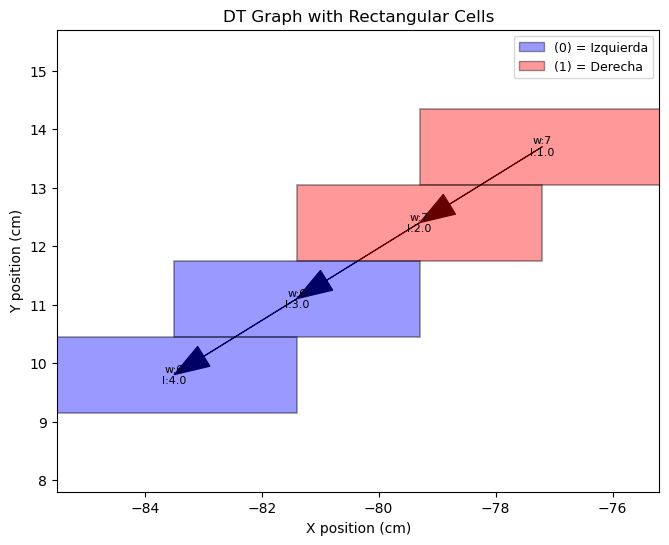

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch

def draw_dt_graph_enhanced(
    data,
    cell_width=4.2,
    cell_height=1.3,
    draw_arrows=True,
    annotate_nodes=True
):
    coords = data.x[:, [3, 4]].cpu().numpy()
    edges = data.edge_index.cpu().numpy()

    labels = None
    if hasattr(data, 'y') and data.y is not None:
        labels = data.y.cpu().numpy()

    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')

    if draw_arrows:
        for e in range(edges.shape[1]):
            i = edges[0, e]
            j = edges[1, e]
            sx, sy = coords[i, 0], coords[i, 1]
            tx, ty = coords[j, 0], coords[j, 1]
            dx = tx - sx
            dy = ty - sy
            plt.arrow(
                sx, sy, dx, dy,
                head_width=0.4,
                length_includes_head=True,
                color='black',
                alpha=1,
                linewidth=0.8
            )
    else:
        for e in range(edges.shape[1]):
            i = edges[0, e]
            j = edges[1, e]
            x_vals = [coords[i, 0], coords[j, 0]]
            y_vals = [coords[i, 1], coords[j, 1]]
            plt.plot(x_vals, y_vals, 'k-', alpha=0.3)

    for idx, (cx, cy) in enumerate(coords):
        rect_x = cx - (cell_width / 2.0)
        rect_y = cy - (cell_height / 2.0)
        
        edge_color = 'black'
        face_color = 'white'
        if labels is not None:
            if labels[idx] == 1:
                face_color = 'red'
            else:
                face_color = 'blue'

        rect = Rectangle(
            (rect_x, rect_y),
            cell_width,
            cell_height,
            linewidth=1.2,
            edgecolor=edge_color,
            facecolor=face_color,
            alpha=0.4
        )
        ax.add_patch(rect)

        if annotate_nodes:
            wire = data.x[idx, 2].item()
            digi_layer = data.x[idx, 0].item()
            label_txt = f"w:{wire:.0f}\nl:{digi_layer:.1f}"
            ax.text(
                cx, cy,
                label_txt,
                ha='center', va='center',
                fontsize=8,
                color='black'
            )

    # Añadir leyenda personalizada
    legend_elements = [
        Patch(facecolor='blue',alpha=0.4, edgecolor='black', label='(0) = Izquierda'),
        Patch(facecolor='red',alpha=0.4, edgecolor='black', label='(1) = Derecha')
        
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)

    plt.xlabel("X position (cm)")
    plt.ylabel("Y position (cm)")
    plt.title("DT Graph with Rectangular Cells")
    plt.grid(False)

    margin = 2.0
    x_min, x_max = np.min(coords[:,0]) - margin, np.max(coords[:,0]) + margin
    y_min, y_max = np.min(coords[:,1]) - margin, np.max(coords[:,1]) + margin
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.show()
draw_dt_graph_enhanced(graphs[108])

In [44]:
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def fit_scalers(graphs):
    all_x = torch.cat([g.x for g in graphs], dim=0).numpy()
    all_edge_attr = torch.cat([g.edge_attr for g in graphs if g.edge_attr is not None], dim=0).numpy()
    scaler_x = StandardScaler().fit(all_x)
    scaler_edge = StandardScaler().fit(all_edge_attr)
    return scaler_x, scaler_edge

def normalize_with_scalers(graphs, scaler_x, scaler_edge):
    normalized_graphs = []
    for g in graphs:
        x_norm = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float)
        
        if g.edge_attr is not None:
            edge_attr_norm = torch.tensor(scaler_edge.transform(g.edge_attr.numpy()), dtype=torch.float)
        else:
            # Si no tiene edge_attr, ponemos un tensor de ceros del tamaño esperado
            edge_index = g.edge_index
            num_edges = edge_index.size(1)
            edge_attr_norm = torch.zeros((num_edges, scaler_edge.mean_.shape[0]), dtype=torch.float)

        g_norm = Data(
            x=x_norm,
            edge_index=g.edge_index,
            y=g.y,
            edge_attr=edge_attr_norm
        )
        normalized_graphs.append(g_norm)
    return normalized_graphs


# 1. Dividir antes de normalizar
train_raw, otros_raw = train_test_split(graphs, test_size=0.2, random_state=42)
validation_raw, test_raw = train_test_split(otros_raw, test_size=0.5, random_state=42)

# 2. Fit de scalers solo con entrenamiento
scaler_x, scaler_edge = fit_scalers(train_raw)

# 3. Aplicar normalización a cada partición
train_dataset = normalize_with_scalers(train_raw, scaler_x, scaler_edge)
validation_dataset = normalize_with_scalers(validation_raw, scaler_x, scaler_edge)
test_dataset = normalize_with_scalers(test_raw, scaler_x, scaler_edge)

# 4. Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=20, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)



In [45]:
grafo = train_dataset[10]
print("Primer grafo normalizado:")
print(grafo)
print("Nodos segmentos:", grafo.y)
print("Características de los nodos (x):", grafo.x)
print("Índices de las aristas (edge_index):", grafo.edge_index)
print("Atributos de las aristas (edge_attr):", grafo.edge_attr)
print("Etiquetas (y):", grafo.y)

Primer grafo normalizado:
Data(x=[7, 6], edge_index=[2, 5], edge_attr=[5, 5], y=[7])
Nodos segmentos: tensor([0, 1, 0, 1, 0, 1, 0])
Características de los nodos (x): tensor([[-1.3476, -0.9405, -0.5674, -0.7241,  1.1261,  1.0547],
        [-0.4450, -0.9405, -0.5101, -0.6936,  1.0163,  0.7639],
        [ 0.4577, -0.9405, -0.5674, -0.7241,  0.9064, -0.0094],
        [ 1.3603, -0.9405, -0.5101, -0.6936,  0.7965,  1.7074],
        [-1.3476,  1.0633, -0.6820, -0.7850, -0.8602, -0.3995],
        [ 0.4577,  1.0633, -0.6820, -0.7850, -1.0799, -0.9529],
        [ 1.3603,  1.0633, -0.6820, -0.8155, -1.1898,  1.7287]])
Índices de las aristas (edge_index): tensor([[0, 1, 2, 5, 3],
        [1, 2, 3, 6, 4]])
Atributos de las aristas (edge_attr): tensor([[ 0.3286,  0.3697, -0.3074,  0.5755,  0.3697],
        [-0.3323,  0.3697, -0.3074, -0.6763,  0.3697],
        [ 0.3286,  0.3697, -0.3074,  0.5755,  0.3697],
        [-0.3323,  0.3697, -0.3074, -0.0504,  0.3697],
        [-0.9931, -2.7049,  1.9606, -1.

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv
from torch import nn
# FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        """
        Focal Loss para clasificación binaria.

        Args:
        - gamma (float): Controla cuánto más duro se penalizan los ejemplos mal clasificados. valores entre 1 y 5
        - alpha (float): Ajusta el peso de las muestras positivas frente a las negativas. valores de 0 a 1
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, preds, targets):
        """
        Calcula la focal loss.
        
        Args:
        - preds: Predicciones del modelo (logits antes de aplicar la función sigmoid).
        - targets: Etiquetas reales binarias (0 para ruido, 1 para segmento).
        
        Returns:
        - Valor de la pérdida.
        """
        preds = preds.view(-1)  # Aplana las predicciones
        targets = targets.view(-1)  # Aplana las etiquetas reales
        
        # Calcula la BCE estándar
        bce_loss = F.binary_cross_entropy_with_logits(preds, targets, reduction="none")
        
        # Calcula la probabilidad de predicción correcta
        pt = torch.exp(-bce_loss)  # pt = P(y=1) para predicciones correctas
        
        # Aplica el peso de la focal loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()
    
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_attr_dim, heads=1, dropout=0.35):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.norm1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = GATConv(hidden_channels, hidden_channels, edge_dim=edge_attr_dim, heads=heads, concat=True)
        self.norm2 = nn.BatchNorm1d(hidden_channels * heads)

        self.conv3 = SAGEConv(hidden_channels * heads, hidden_channels)
        self.norm3 = nn.BatchNorm1d(hidden_channels)

        self.conv4 = GATConv(hidden_channels, out_channels, edge_dim=edge_attr_dim, heads=1, concat=False)

        self.dropout = nn.Dropout(p=dropout)
        self.res_proj = nn.Linear(hidden_channels * heads, hidden_channels)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        res = x
        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        res = self.res_proj(res)
        x = F.relu(x + res)
        x = self.dropout(x)

        x = self.conv4(x, edge_index, edge_attr)
        return x


# Seleccionar GPU si no esta disponible pues CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')  # 'cuda' o 'cpu'

Device: cpu


In [47]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, f1_score

# Defino el modelo
# Parametros
input_dim = 6   # x, y positions
hidden_dim = 100 # Dimensiones ocultas
output_dim = 2  # Numero de clases (nodo verdad 1 o no 0)
edge_attr_dim = 5

#model = GCN_2(input_dim, hidden_dim, output_dim, edge_attr_dim)
model = GCN(input_dim, hidden_dim, 1, edge_attr_dim) #output = 1 por el focalloss
lr, weight_decay = 0.001, 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5, verbose=True)

# perdida
pos_weight = torch.tensor([0.97]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#gamma, alpha = 3, 0.5
#loss_fn = FocalLoss(gamma, alpha)  # Focal Loss con balanceo de clases
#loss_fn = nn.CrossEntropyLoss(weight = class_weights)

def plot_confusion(all_preds,all_labels,epoch):
    # matriz de confusion y el F1-score
    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion - Epoch {epoch + 1}')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

def generar_malas_predicciones(preds, labels, malas_predicciones):
    # lista para ver si hay alguna relacion entre las malas predicciones y el nodo 
    for node_idx in range(len(preds)):  
        if preds[node_idx][0] != labels[node_idx][0]:  # Si la prediccion es incorrecta
            malas_predicciones.append({
                'data': data,
                'node_idx': node_idx,
                'nodo': data.x[node_idx],
                'prediccion': preds[node_idx],
                'real_label': labels[node_idx]
            })


threshold = 0.5 #supongo q es 0.5?
def train(data, loss_fn):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)# Forward pass
    loss = loss_fn(out, data.y) # Calcular perdida
    loss.backward()
    optimizer.step()
    #preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
    preds =(torch.sigmoid(out) > threshold).float() # lo convierto a float para q no sea true/false
    labels = data.y.cpu().numpy()  # Etiquetas verdaderas
    return loss, preds, labels

def evaluacion(data):
    model.eval()
    data = data.to(device)
    logits = model(data.x, data.edge_index, data.edge_attr)
    loss = loss_fn(logits, data.y)
    #preds = torch.argmax(logits, dim=1)
    preds = (torch.sigmoid(logits) > threshold).float()
    return loss, preds, logits


/home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/80, Train Loss: 0.6932, Val accuracy: 0.5555, Clase 0 val: Recall : 0.5396, F1-Scores: 0.5417, Clase 1 val: Recall : 0.5576, F1-Scores: 0.5555
Epoch 2/80, Train Loss: 0.6132, Val accuracy: 0.6287, Clase 0 val: Recall : 0.9152, F1-Scores: 0.7531, Clase 1 val: Recall : 0.4964, F1-Scores: 0.6287
Epoch 3/80, Train Loss: 0.5303, Val accuracy: 0.7057, Clase 0 val: Recall : 0.9136, F1-Scores: 0.7836, Clase 1 val: Recall : 0.5913, F1-Scores: 0.7057
Epoch 4/80, Train Loss: 0.5017, Val accuracy: 0.7104, Clase 0 val: Recall : 0.9079, F1-Scores: 0.7837, Clase 1 val: Recall : 0.6004, F1-Scores: 0.7104
Epoch 5/80, Train Loss: 0.4931, Val accuracy: 0.7272, Clase 0 val: Recall : 0.8971, F1-Scores: 0.7880, Clase 1 val: Recall : 0.6288, F1-Scores: 0.7272
Epoch 6/80, Train Loss: 0.4888, Val accuracy: 0.7283, Clase 0 val: Recall : 0.8909, F1-Scores: 0.7864, Clase 1 val: Recall : 0.6337, F1-Scores: 0.7283
Epoch 7/80, Train Loss: 0.4846, Val accuracy: 0.7238, Clase 0 val: Recall : 0.9080, F1-Scores:

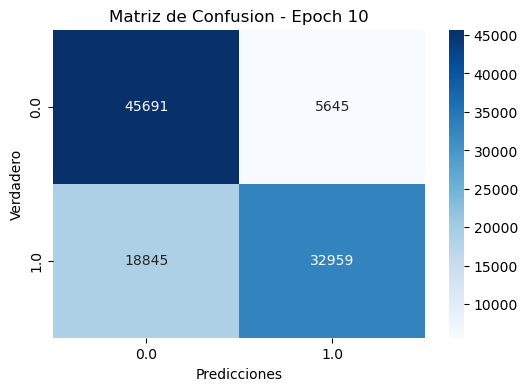

Epoch 11/80, Train Loss: 0.4776, Val accuracy: 0.7267, Clase 0 val: Recall : 0.9077, F1-Scores: 0.7913, Clase 1 val: Recall : 0.6222, F1-Scores: 0.7267
Epoch 12/80, Train Loss: 0.4759, Val accuracy: 0.7268, Clase 0 val: Recall : 0.9068, F1-Scores: 0.7910, Clase 1 val: Recall : 0.6229, F1-Scores: 0.7268
Epoch 13/80, Train Loss: 0.4738, Val accuracy: 0.7295, Clase 0 val: Recall : 0.8973, F1-Scores: 0.7892, Clase 1 val: Recall : 0.6319, F1-Scores: 0.7295


KeyboardInterrupt: 

In [15]:
# epocas
epochs = 80

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
malas_predicciones=[]

# entrenamiento
for epoch in range(epochs):
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 
        data.y = data.y.float()  
        data.y = data.y.view(-1, 1)  # la salida del modelo es tipo (batch_size, 1), pero data.y tiene forma (batch_size), asi q lo cambio
        loss, preds, labels = train(data, loss_fn)
        epoch_loss += loss.item()
        all_preds.extend(preds)
        all_labels.extend(labels)
        
        # CONFIDENCE SCORE en la ultima epoca
        if epoch == epochs-1:          
            generar_malas_predicciones(preds, labels, malas_predicciones)
    scheduler.step(epoch_loss)
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            loss, preds, logits = evaluacion(data)
            val_loss += loss.item()
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())  

    val_losses.append(val_loss/len(validation_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))
    
    cr_val = classification_report(all_labels_val, all_preds_val, target_names=["Clase 0", "Clase 1"], output_dict=True)
    recall_clase_0 = cr_val["Clase 0"]["recall"]
    f1_score_clase_0 = cr_val["Clase 0"]["f1-score"]
    recall_clase_1 = cr_val["Clase 1"]["recall"]
    f1_score_clase_1 = cr_val["Clase 1"]["f1-score"]
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Val accuracy: {f1_score(all_labels_val, all_preds_val):.4f}, Clase 0 val: Recall : {recall_clase_0:.4f}, F1-Scores: {f1_score_clase_0:.4f}, Clase 1 val: Recall : {recall_clase_1:.4f}, F1-Scores: {f1_score_clase_1:.4f}")
    
    # matriz de confusion
    if (epoch+1)%10==0:
        plot_confusion(all_preds, all_labels, epoch)
    # Guardar modelo cada 10 epochs
    if (epoch + 1) % 10 == 0 and (epoch + 1) >= 80:
        torch.save(model.state_dict(), f"modelo_epoch_{epoch+1}.pth")

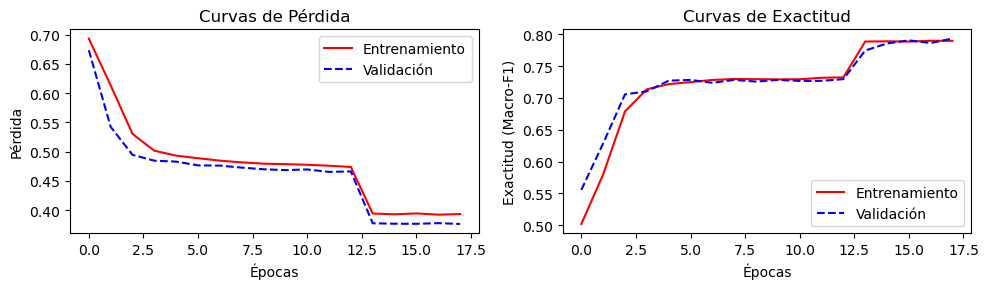

In [29]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))

    # Curva de pérdidas
    ax[0].plot(train_losses, 'r-', label='Entrenamiento')
    ax[0].plot(val_losses, 'b--', label='Validación')
    ax[0].set_xlabel('Épocas')
    ax[0].set_ylabel('Pérdida')
    
    ax[0].set_title('Curvas de Pérdida')
    ax[0].legend()

    # Curva de accuracies (macro-f1 en tu caso)
    ax[1].plot(train_accuracies, 'r-', label='Entrenamiento')
    ax[1].plot(val_accuracies, 'b--', label='Validación')
    ax[1].set_xlabel('Épocas')
    ax[1].set_ylabel('Exactitud (Macro-F1)')
    ax[1].set_title('Curvas de Exactitud')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [ ]:

# Guarda los pesos del modelo actual
#torch.save(model.state_dict(), 'modelo_bueno_ambi.pth')

# Para recargar el modelo guardado
'''model = GCN(input_dim, hidden_dim, 1, edge_attr_dim)
model.load_state_dict(torch.load('modelo_bueno_ambi.pth'))
model.to(device)
model.eval()  # Si es para hacer predicciones'''

GCN(
  (conv1): SAGEConv(6, 100, aggr=mean)
  (norm1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATConv(100, 100, heads=1)
  (norm2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): SAGEConv(100, 100, aggr=mean)
  (norm3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): GATConv(100, 1, heads=1)
  (dropout): Dropout(p=0.35, inplace=False)
  (res_proj): Linear(in_features=100, out_features=100, bias=True)
)

Epoch 1/5, Train Loss: 0.3943, Val accuracy: 0.7745, Clase 0 val: Recall : 0.7817, F1-Scores: 0.7738, Clase 1 val: Recall : 0.7668, F1-Scores: 0.7745
Epoch 2/5, Train Loss: 0.3929, Val accuracy: 0.7856, Clase 0 val: Recall : 0.7476, F1-Scores: 0.7685, Clase 1 val: Recall : 0.8065, F1-Scores: 0.7856
Epoch 3/5, Train Loss: 0.3944, Val accuracy: 0.7904, Clase 0 val: Recall : 0.7347, F1-Scores: 0.7670, Clase 1 val: Recall : 0.8229, F1-Scores: 0.7904
Epoch 4/5, Train Loss: 0.3923, Val accuracy: 0.7863, Clase 0 val: Recall : 0.7422, F1-Scores: 0.7669, Clase 1 val: Recall : 0.8111, F1-Scores: 0.7863
Epoch 5/5, Train Loss: 0.3933, Val accuracy: 0.7932, Clase 0 val: Recall : 0.7222, F1-Scores: 0.7641, Clase 1 val: Recall : 0.8358, F1-Scores: 0.7932
              precision    recall  f1-score   support

     Clase 0       0.81      0.73      0.77      6326
     Clase 1       0.76      0.83      0.80      6537

    accuracy                           0.78     12863
   macro avg       0.79      0.7

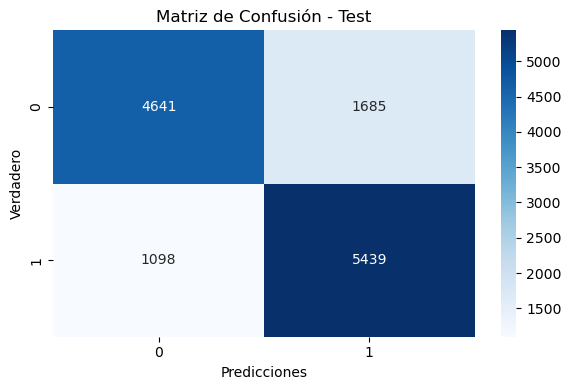

In [18]:
#pequeño reentrenamiento bajando el learning rate
# epocas
epochs_2 = 5

lr, weight_decay = 0.000001, 1e-6
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay) # perdida
pos_weight = torch.tensor([0.96]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# entrenamiento
for epoch in range(epochs_2):
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 
        data.y = data.y.float()  
        data.y = data.y.view(-1, 1)  # la salida del modelo es tipo (batch_size, 1), pero data.y tiene forma (batch_size), asi q lo cambio
        loss, preds, labels = train(data, loss_fn)
        epoch_loss += loss.item()
        all_preds.extend(preds)
        all_labels.extend(labels)
    
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            loss, preds, logits = evaluacion(data)
            val_loss += loss.item()
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())  

    val_losses.append(val_loss/len(validation_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))
    
    cr_val = classification_report(all_labels_val, all_preds_val, target_names=["Clase 0", "Clase 1"], output_dict=True)
    recall_clase_0 = cr_val["Clase 0"]["recall"]
    f1_score_clase_0 = cr_val["Clase 0"]["f1-score"]
    recall_clase_1 = cr_val["Clase 1"]["recall"]
    f1_score_clase_1 = cr_val["Clase 1"]["f1-score"]
    print(f"Epoch {epoch + 1}/{epochs_2}, Train Loss: {epoch_loss/len(train_loader):.4f}, Val accuracy: {f1_score(all_labels_val, all_preds_val):.4f}, Clase 0 val: Recall : {recall_clase_0:.4f}, F1-Scores: {f1_score_clase_0:.4f}, Clase 1 val: Recall : {recall_clase_1:.4f}, F1-Scores: {f1_score_clase_1:.4f}")
    
    # matriz de confusion
    if (epoch+1)%epochs==0:
        plot_confusion(all_preds, all_labels, epoch)
    # Guardar modelo cada 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"modelo_epoch_{epoch+1+epochs}.pth")


def evaluar_modelo(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if data.edge_index.numel() == 0:
                continue
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.edge_attr)

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().view(-1)
            true_labels = data.y.view(-1)

            all_preds.append(preds.cpu())
            all_labels.append(true_labels.cpu())


    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Reporte de clasificación y matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"])
    print(report)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.title('Matriz de Confusión - Test')
    plt.tight_layout()
    plt.show()
evaluar_modelo(model, test_loader, device, threshold=threshold)

              precision    recall  f1-score   support

     Clase 0       0.77      0.79      0.78      6326
     Clase 1       0.79      0.77      0.78      6537

    accuracy                           0.78     12863
   macro avg       0.78      0.78      0.78     12863
weighted avg       0.78      0.78      0.78     12863



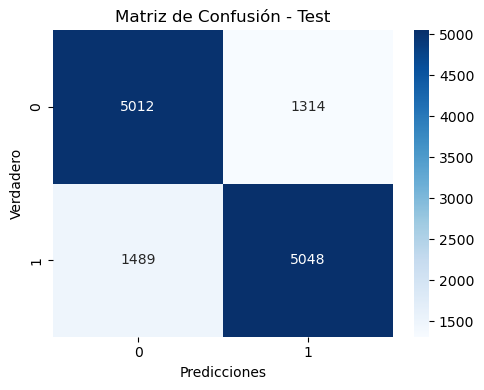

In [55]:
#===========================================
# Evaluación del modelo
#===========================================
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_modelo(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    errores = []  # Lista para guardar nodos mal clasificados

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if data.edge_index.numel() == 0:
                continue
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.edge_attr)

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().view(-1)
            true_labels = data.y.view(-1)

            all_preds.append(preds.cpu())
            all_labels.append(true_labels.cpu())

            # Detectar nodos mal clasificados
            incorrectos = (preds != true_labels).nonzero(as_tuple=True)[0]
            for idx in incorrectos:
                errores.append({
                    'grafo': data.cpu().clone(),
                    'grafo_id': i,
                    'nodo_id': int(idx),
                    'etiqueta_real': int(true_labels[idx]),
                    'etiqueta_predicha': int(preds[idx])
                })


    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Reporte de clasificación y matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"])
    print(report)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.title('Matriz de Confusión - Test')
    plt.tight_layout()
    plt.show()

    # Convertir errores en un DataFrame para inspección
    df_errores = pd.DataFrame(errores)
    return df_errores

# Uso:
df_incorrectos = evaluar_modelo(model, test_loader, device, threshold=0.5)
df_incorrectos = df_incorrectos.groupby('grafo_id').agg({
    'grafo': 'first',
    'nodo_id': list,
    'etiqueta_real': list,
    'etiqueta_predicha': list
}).reset_index()



In [33]:
# gridsearch_f1_analysis.py

import torch
import torch.nn as nn
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np
import os

# Definir rutas
save_folder = "modelos_gridsearch"
os.makedirs(save_folder, exist_ok=True)

# Definir rangos a explorar
dropouts = [0.2, 0.3, 0.4, 0.5]
pos_weights = [0.7, 0.8, 0.9, 1.0, 1.1]

# Guardar resultados
results = []
best_macro_f1 = 0.0
best_model_info = None

#for dropout in dropouts:
dropout=0.4
for pw in pos_weights:
    model = GCN(input_dim, 100, 1, edge_attr_dim, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(device))

    for epoch in range(30):
        model.train()
        for data in train_loader:
            if data.edge_index.numel() == 0:
                continue
            data.y = data.y.float().view(-1, 1).to(device)
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.edge_attr)
            loss = loss_fn(out, data.y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:
                continue
            data.y = data.y.float().view(-1, 1).to(device)
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.edge_attr)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    f1_class1 = f1_score(all_labels, all_preds, pos_label=0)
    f1_class2 = f1_score(all_labels, all_preds, pos_label=1)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    results.append((dropout, pw, f1_class1, f1_class2, macro_f1))

    print(f"dropout={dropout}, pos_weight={pw} --> F1[0]={f1_class1:.4f}, F1[1]={f1_class2:.4f}, MacroF1={macro_f1:.4f}")

    if macro_f1 > best_macro_f1:
        model_name = f"model_drop{dropout}_pw{pw:.2f}_macroF1{macro_f1:.4f}.pth"
        save_path = os.path.join(save_folder, model_name)
        torch.save(model.state_dict(), save_path)
        best_macro_f1 = macro_f1
        best_model_info = (save_path, dropout, pw, f1_class1, f1_class2, macro_f1)

print("\n=== Mejor Modelo Encontrado ===")
print(f"Path : {best_model_info[0]}")
print(f"Dropout : {best_model_info[1]}")
print(f"Pos weight : {best_model_info[2]}")
print(f"F1 clase 0 : {best_model_info[3]:.4f}")
print(f"F1 clase 1 : {best_model_info[4]:.4f}")
print(f"Macro F1 : {best_model_info[5]:.4f}")

# Matriz para gráfico 2D
hd_vals = np.array([r[0] for r in results])
pw_vals = np.array([r[1] for r in results])
f1_vals = np.array([r[4] for r in results])

hd_unique = sorted(set(hd_vals))
pw_unique = sorted(set(pw_vals))
f1_matrix = np.zeros((len(pw_unique), len(hd_unique)))

for hd, pw, _, _, macro_f1 in results:
    i = pw_unique.index(pw)
    j = hd_unique.index(hd)
    f1_matrix[i, j] = macro_f1

plt.figure(figsize=(8, 6))
im = plt.imshow(f1_matrix, cmap='cividis', origin='lower', aspect='auto')
plt.xticks(np.arange(len(hd_unique)), hd_unique)
plt.yticks(np.arange(len(pw_unique)), pw_unique)
plt.xlabel('Dropout')
plt.ylabel('Pos Weight')
plt.title('Macro F1 Score en función de Dropout y Pos Weight')
plt.colorbar(im, label='Macro F1 Score')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# Union de varios modelos para mejorar el f1-score

              precision    recall  f1-score   support

     Clase 0       0.82      0.72      0.77      6326
     Clase 1       0.76      0.85      0.80      6537

    accuracy                           0.78     12863
   macro avg       0.79      0.78      0.78     12863
weighted avg       0.79      0.78      0.78     12863



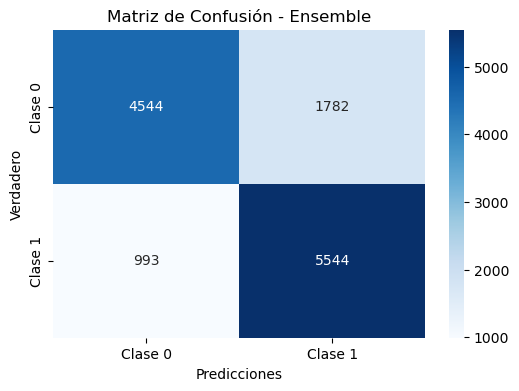

In [56]:
import torch

# Lista de rutas de los modelos que quieres usar
model_paths = [
    'modelo_bueno_ambi.pth',
    "modelo_epoch_90.pth",
    "modelo_epoch_100.pth",
]

# Cargar todos los modelos
models = []
for path in model_paths:
    m = GCN(input_dim, hidden_dim, 1, edge_attr_dim)  # Crea nueva instancia
    m.load_state_dict(torch.load(path, map_location=device))  # Carga pesos
    m.to(device)
    m.eval()  # Modo evaluación
    models.append(m)

# Ahora evaluamos
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        if data.edge_index.numel() == 0:
            continue
        data = data.to(device)

        # Predicción de cada modelo
        preds_modelos = []
        for m in models:
            logits = m(data.x, data.edge_index, data.edge_attr)
            probs = torch.sigmoid(logits)
            preds_modelos.append(probs)

        # Hacer la media de todas las predicciones
        mean_probs = torch.mean(torch.stack(preds_modelos), dim=0)

        # Umbral de clasificación
        final_preds = (mean_probs > 0.5).float()

        all_preds.append(final_preds.cpu())
        all_labels.append(data.y.cpu())

# Concatenar todo
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Evaluar resultados
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=["Clase 0", "Clase 1"]))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
plt.xlabel('Predicciones')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión - Ensemble')
plt.show()


# ROC

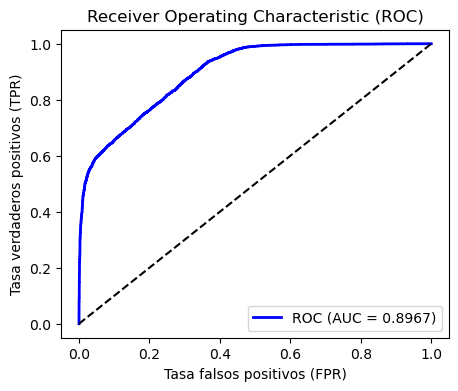

In [57]:
from sklearn.metrics import roc_curve, auc
def probs_labels(model, dataloader, device):
    all_probs = []  # Probabilidades para la clase positiva
    all_labels = []  # Etiquetas verdaderas

    model.eval()
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            out = model(data.x, data.edge_index, data.edge_attr)
            probs = torch.sigmoid(out).cpu().numpy().flatten()  # Correcto para output_dim=1
            labels = data.y.cpu().numpy()

            all_probs.extend(probs.tolist()) 
            all_labels.extend(labels.tolist()) 
    return all_probs, all_labels

def roc_y_auc(all_probs, all_labels):
    FPR, TPR, _ = roc_curve(all_labels, all_probs) #tasa falsos positivos y tasa verdaderos positivos
    roc_auc = auc(FPR, TPR) #area bajo la ROC

    plt.figure(figsize = (5,4))
    plt.plot(FPR, TPR, color ='b', lw=2, label = f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonal
    plt.xlabel('Tasa falsos positivos (FPR)')
    plt.ylabel('Tasa verdaderos positivos (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

all_probs, all_labels = probs_labels(model, test_loader, device)
roc_y_auc(all_probs, all_labels)